## **Random Forest**

In [21]:
# Dataset 
import pandas as pd
df = pd.read_csv('../data/processed.csv')

# Importar funciones de entrenamiento y métricas
from functions import modelo_rf, metricas

### **Modelo entrenado con todas las variables**

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.91      0.98      0.95       189
           2       0.88      0.69      0.77        32

    accuracy                           0.91       229
   macro avg       0.60      0.56      0.57       229
weighted avg       0.88      0.91      0.89       229



c:\Users\diana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\diana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\diana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


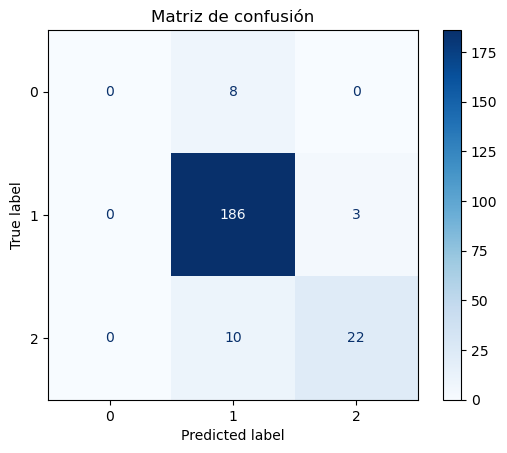

In [22]:
rf, X_test, y_test = modelo_rf(df,None,200)
metricas(rf,X_test,y_test)

### **Modelo entrenado con variables seleccionadas**

Este modelo se entrena eliminando las variables que , con base en los diagramas de cajas y bigotes realizados en el EDA, se observó que poseían un bajo poder discriminante entre clases.

Los resultados muestran una ligera mejora en la predicción de los vinos malos, clasificando correctamente 1 vino malo, de 8 predicciones. Además, la precisión del modelo se mantiene en 0.88.

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.91      0.99      0.95       189
           2       0.96      0.69      0.80        32

    accuracy                           0.92       229
   macro avg       0.62      0.56      0.58       229
weighted avg       0.89      0.92      0.90       229



c:\Users\diana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\diana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\diana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


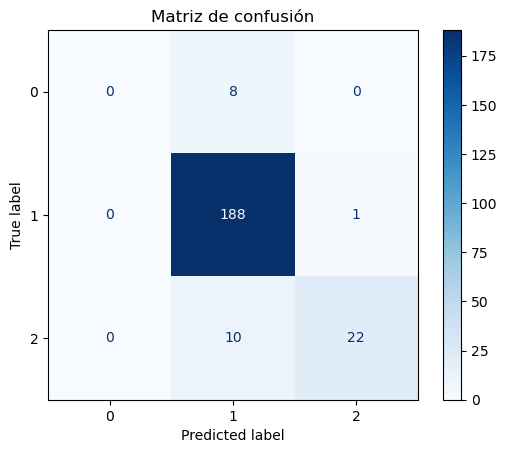

In [23]:
drop_vars = ['residual sugar','chlorides','free sulfur dioxide','total sulfur dioxide']
rf, X_test, y_test = modelo_rf(df,drop_vars,200)
metricas(rf,X_test,y_test)

### **Modelo entrenado con variables seleccionadas y sin outliers de la clase "medio"**

In [24]:
# Eliminación de outliers en calidad "medio" (clase mayoritaria) fuera de los límites globales (máximo y mínimo de cada variable, por clase)
vars = df.drop(columns=['quality_label']).columns
df_new = df.copy()

for var in vars:

    maximos = []
    minimos = []

    # calcular límites por clase
    for clase in [0, 1, 2]:

        obs = df_new[df_new['quality_label'] == clase][var]

        q = obs.quantile([0.25, 0.75])

        IQR = q[0.75] - q[0.25]

        min_v = q[0.25] - 1.5 * IQR
        max_v = q[0.75] + 1.5 * IQR

        minimos.append(min_v)
        maximos.append(max_v)

    # límites globales
    min_global = min(minimos)
    max_global = max(maximos)

    df_new = df_new[
      (df_new['quality_label'] != 1) |
      (
          (df_new['quality_label'] == 1) &
          (df_new[var] >= min_global) &
          (df_new[var] <= max_global)
      )
    ]

df_new["quality_label"].value_counts()

quality_label
1    777
2    159
0     39
Name: count, dtype: int64

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.84      0.99      0.91       155
           2       0.85      0.34      0.49        32

    accuracy                           0.84       195
   macro avg       0.56      0.44      0.47       195
weighted avg       0.81      0.84      0.80       195



c:\Users\diana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\diana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\diana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


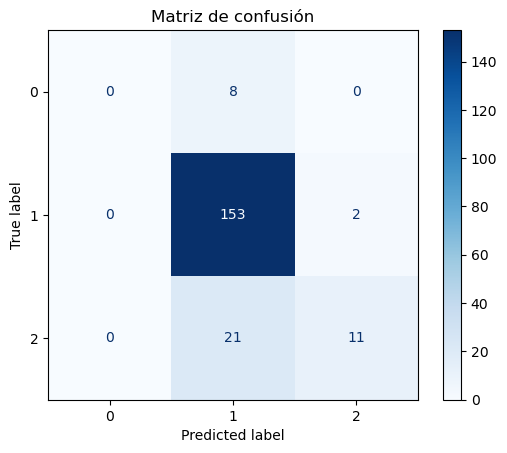

In [25]:
rf, X_test, y_test = modelo_rf(df_new,drop_vars,200)
metricas(rf,X_test,y_test)


# **Regresión logística**

In [26]:
from functions import modelo_rl,  metricas_lr

### **Modelo entrenado con todas las variables**

              precision    recall  f1-score   support

           0       0.08      0.62      0.15         8
           1       0.94      0.55      0.69       189
           2       0.45      0.81      0.58        32

    accuracy                           0.59       229
   macro avg       0.49      0.66      0.47       229
weighted avg       0.84      0.59      0.66       229

                Variable  Coeficiente
10               alcohol    -0.881655
7                density    -0.563992
5    free sulfur dioxide    -0.258825
6   total sulfur dioxide     0.001942
2            citric acid     0.033883
9              sulphates     0.040240
4              chlorides     0.292462
3         residual sugar     0.343708
0          fixed acidity     0.635917
8                     pH     0.759334
1       volatile acidity     0.942453


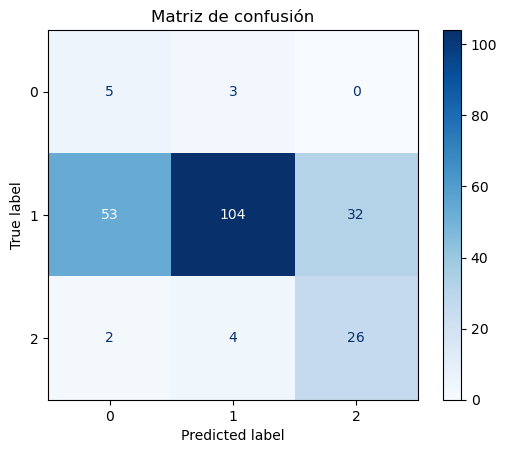

In [27]:
logreg, X_test_scaled, y_test, columnas = modelo_rl(df,None)
metricas_lr(logreg, X_test_scaled, y_test, columnas)

### **Modelo entrenado con variables seleccionadas**

              precision    recall  f1-score   support

           0       0.07      0.50      0.12         8
           1       0.94      0.54      0.69       189
           2       0.43      0.84      0.57        32

    accuracy                           0.59       229
   macro avg       0.48      0.63      0.46       229
weighted avg       0.84      0.59      0.65       229

           Variable  Coeficiente
6           alcohol    -0.648556
3           density    -0.113121
5         sulphates     0.090797
0     fixed acidity     0.160732
2       citric acid     0.245286
4                pH     0.495994
1  volatile acidity     1.015164


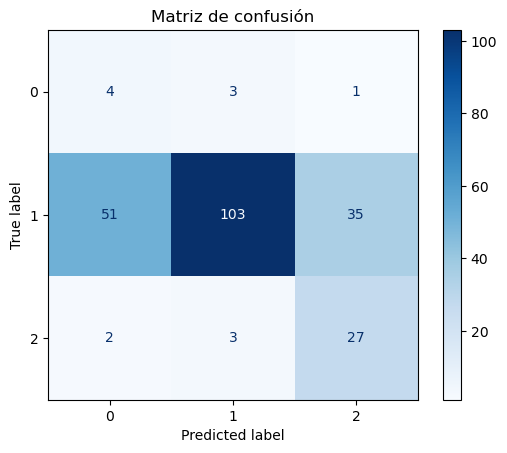

In [28]:
logreg, X_test_scaled, y_test, columnas = modelo_rl(df,drop_vars)
metricas_lr(logreg, X_test_scaled, y_test, columnas)

### **Modelo entrenado con variables seleccionadas y sin outliers de la clase "medio"**

              precision    recall  f1-score   support

           0       0.11      0.50      0.18         8
           1       0.93      0.60      0.73       155
           2       0.46      0.84      0.59        32

    accuracy                           0.64       195
   macro avg       0.50      0.65      0.50       195
weighted avg       0.82      0.64      0.68       195

           Variable  Coeficiente
6           alcohol    -0.659159
3           density    -0.078982
0     fixed acidity     0.070040
5         sulphates     0.088977
2       citric acid     0.338927
4                pH     0.444767
1  volatile acidity     1.044687


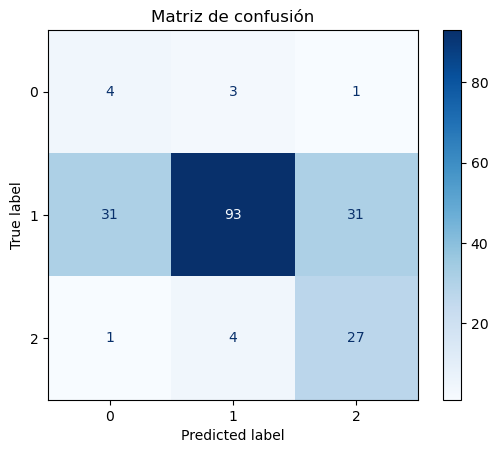

['../models/logistic_regression.pkl']

In [29]:
import joblib

# Mejor modelo
modelo, X_test_scaled, y_test, columnas = modelo_rl(df_new,drop_vars)
resultados = metricas_lr(modelo, X_test_scaled, y_test, columnas)
joblib.dump(modelo, '../models/logistic_regression.pkl')

In [30]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns= columnas)

X_test_scaled_df.to_csv('../data/X_test_scaled.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)


**¿Cuáles serían las mejores métricas para la evaluación del modelo?**

Debido al desbalance de clases en el dataset, la métrica principal sería el recall de la clase “malo”, ya que el objetivo es maximizar la detección de vinos de mala calidad y reducir los falsos negativos (vinos malos clasificados como no malos).

También se consideraría la accuracy como referencia general del desempeño.

### **Selección del mejor modelo**

Aunque los modelos de random forest tienen una accuracies muy altas (0.91,0.92,0.84), no predicen correctamente ningún vino de calidad "mala" (clase minoritaria).  

En contraste, los modelos de regresión logística dan mejores resultados, lo cual puede deberse a que las variables poseen una relación aproximadamente lineal con las clases y por lo tanto, captura de manera más precisa ésta relación y las fronteras de división entre clases son más simples

Entre los modelos de regresión logística hay diferencias relativamente pequeñas entre las métricas:

- Con todas las variables: recall en malo (0.62) accuracy (0.59)

- Con variables seleccionadas: recall en malo (0.50) accuracy (0.59)

- Con variables seleccionadas y sin outliers en malo: recall (0.50) accuracy (0.64)

Aunque el recall de la clase “malo” es más alto en el modelo que utiliza todas las variables, el último modelo presenta un mejor f1-score en todas las clases, métrica que combina tanto la precisión como el recall, ya que no solo nos interesa el aprendizaje del modelo en la clase minoritaria sino en todas las existentes. Además, este modelo utiliza un menor número de variables, lo que reduce su complejidad y favorece una mejor capacidad de generalización. Asimismo, la eliminación de outliers contribuye a disminuir el ruido en los datos, mejorando así el desempeño global del modelo.
